Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Mean: [ 1.73585359e-17 -2.16981699e-17  6.94341436e-17  1.04151215e-16
 -2.60378038e-17 -5.69938595e-16  1.56226823e-16 -3.76101611e-17]
Std: [1. 1. 1. 1. 1. 1. 1. 1.]
Confusion Matrix:
[[78 21]
 [16 39]]
Accuracy: 75.97402597402598 %
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        99
           1       0.65      0.71      0.68        55

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154

The individual is predicted not to have diabetes


c:\Users\bda\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[Text(0.47834201388888886, 0.9705882352941176, 'x[1] <= 0.208\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]'),
 Text(0.18307291666666667, 0.9117647058823529, 'x[7] <= -0.383\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]'),
 Text(0.3307074652777778, 0.9411764705882353, 'True  '),
 Text(0.06666666666666667, 0.8529411764705882, 'x[5] <= -0.134\nentropy = 0.391\nsamples = 221\nvalue = [204, 17]'),
 Text(0.022222222222222223, 0.7941176470588235, 'x[6] <= 0.603\nentropy = 0.068\nsamples = 124\nvalue = [123, 1]'),
 Text(0.011111111111111112, 0.7352941176470589, 'entropy = 0.0\nsamples = 108\nvalue = [108, 0]'),
 Text(0.03333333333333333, 0.7352941176470589, 'x[6] <= 0.646\nentropy = 0.337\nsamples = 16\nvalue = [15, 1]'),
 Text(0.022222222222222223, 0.6764705882352942, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.044444444444444446, 0.6764705882352942, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.1111111111111111, 0.7941176470588235, 'x[2] <= -1.752\nentropy =

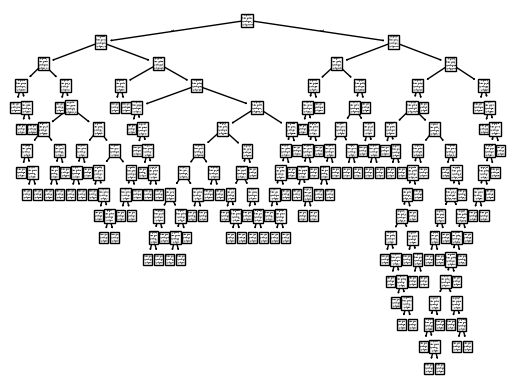

In [7]:
import numpy as np
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Load dataset
df = pd.read_csv("diabetes.csv")

# Check dataset
print(df.isnull().sum())

# Features and target
X = df[
    [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]
]

y = df["Outcome"]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardization
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Check whether StandardScaler worked
print("Mean:", X_train.mean(axis=0))
print("Std:", X_train.std(axis=0))

# Create Decision Tree classifier
classifier = DecisionTreeClassifier(
    criterion="entropy",
    random_state=0
)

# Train the model
classifier.fit(X_train, y_train)

# Predict test data
y_pred = classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100, "%")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))
new_individual = np.array([[
    1,      # Pregnancies
    100,    # Glucose
    70,     # BloodPressure
    20,     # SkinThickness
    79,     # Insulin
    25.0,   # BMI
    0.5,    # DiabetesPedigreeFunction
    25      # Age
]])

# Scale using the SAME scaler
new_individual_scaled = sc.transform(new_individual)

# Predict
prediction = classifier.predict(new_individual_scaled)

if prediction[0] == 1:
    print("The individual is predicted to have diabetes")
else:
    print("The individual is predicted not to have diabetes")

tree.plot_tree(classifier)
